In [1]:
# ============================================================
# MODULE 1: DATASET LOADING AND ORGANIZATION
# Industrial Fan Sound Classification
# ============================================================

import os
import pandas as pd

# ------------------------------------------------------------
# 1. Project Path Setup
# ------------------------------------------------------------

PROJECT_PATH = os.getcwd()

DATASET_PATH = os.path.join(
    PROJECT_PATH,
    "-6_dB_fan",
    "fan"
)

OUTPUT_PATH = os.path.join(
    PROJECT_PATH,
    "Fan_Module1_Output"
)

os.makedirs(OUTPUT_PATH, exist_ok=True)

# Machine IDs
MACHINE_IDS = [
    "id_00",
    "id_02",
    "id_04",
    "id_06"
]

print("Project Path :", PROJECT_PATH)
print("Dataset Path :", DATASET_PATH)
print("Output Path  :", OUTPUT_PATH)


# ------------------------------------------------------------
# 2. Dataset Loading
# ------------------------------------------------------------

records = []

for machine_id in MACHINE_IDS:

    machine_path = os.path.join(
        DATASET_PATH,
        machine_id
    )

    if not os.path.exists(machine_path):
        print(f"Machine folder not found: {machine_id}")
        continue

    # Normal and Abnormal folders
    for condition, label in [
        ("normal", 0),
        ("abnormal", 1)
    ]:

        condition_path = os.path.join(
            machine_path,
            condition
        )

        if not os.path.exists(condition_path):
            print(
                f"Condition folder not found: "
                f"{machine_id}/{condition}"
            )
            continue

        # Read audio files
        for file_name in os.listdir(condition_path):

            if file_name.lower().endswith(
                (".wav", ".wave")
            ):

                file_path = os.path.join(
                    condition_path,
                    file_name
                )

                records.append({
                    "machine_id": machine_id,
                    "file_name": file_name,
                    "file_path": file_path,
                    "condition": condition,
                    "label": label
                })


# ------------------------------------------------------------
# 3. Create DataFrame
# ------------------------------------------------------------

audio_df = pd.DataFrame(records)

print("\nDataset Loading Completed")
print("Total Audio Files:", len(audio_df))


# ------------------------------------------------------------
# 4. Display Dataset Information
# ------------------------------------------------------------

print("\nFirst 5 Records:")
display(audio_df.head())

print("\nDataset Shape:")
print(audio_df.shape)

print("\nColumn Names:")
print(audio_df.columns.tolist())


# ------------------------------------------------------------
# 5. Dataset Summary
# ------------------------------------------------------------

print("\nMachine-wise File Count:")
print(
    audio_df["machine_id"].value_counts()
    .sort_index()
)

print("\nCondition-wise File Count:")
print(
    audio_df["condition"].value_counts()
)

print("\nMachine and Condition Summary:")
print(
    audio_df.groupby(
        ["machine_id", "condition"]
    ).size()
)


# ------------------------------------------------------------
# 6. Check Missing Values
# ------------------------------------------------------------

print("\nMissing Values:")
print(audio_df.isnull().sum())


# ------------------------------------------------------------
# 7. Save Dataset Metadata
# ------------------------------------------------------------

csv_path = os.path.join(
    OUTPUT_PATH,
    "audio_dataset.csv"
)

audio_df.to_csv(
    csv_path,
    index=False
)

print("\nDataset metadata saved successfully!")
print("Saved File:", csv_path)

Project Path : D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification
Dataset Path : D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification\-6_dB_fan\fan
Output Path  : D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification\Fan_Module1_Output

Dataset Loading Completed
Total Audio Files: 5550

First 5 Records:


,machine_id,file_name,file_path,condition,label
0,id_00,00000000.wav,D:\Study Metarial\MIni_Project_PG\Industrial_S...,normal,0
1,id_00,00000001.wav,D:\Study Metarial\MIni_Project_PG\Industrial_S...,normal,0
2,id_00,00000002.wav,D:\Study Metarial\MIni_Project_PG\Industrial_S...,normal,0
3,id_00,00000003.wav,D:\Study Metarial\MIni_Project_PG\Industrial_S...,normal,0
4,id_00,00000004.wav,D:\Study Metarial\MIni_Project_PG\Industrial_S...,normal,0



Dataset Shape:
(5550, 5)

Column Names:
['machine_id', 'file_name', 'file_path', 'condition', 'label']

Machine-wise File Count:
machine_id
id_00    1418
id_02    1375
id_04    1381
id_06    1376
Name: count, dtype: int64

Condition-wise File Count:
condition
normal      4075
abnormal    1475
Name: count, dtype: int64

Machine and Condition Summary:
machine_id  condition
id_00       abnormal      407
            normal       1011
id_02       abnormal      359
            normal       1016
id_04       abnormal      348
            normal       1033
id_06       abnormal      361
            normal       1015
dtype: int64

Missing Values:
machine_id    0
file_name     0
file_path     0
condition     0
label         0
dtype: int64

Dataset metadata saved successfully!
Saved File: D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification\Fan_Module1_Output\audio_dataset.csv


In [2]:
# ============================================================
# MODULE 2: FEATURE EXTRACTION
# Industrial Fan Sound Classification
# 24 Features: 20 MFCC + 4 Spectral Features
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import librosa

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 1. Path Setup
# ------------------------------------------------------------

PROJECT_PATH = os.getcwd()

MODULE1_PATH = os.path.join(
    PROJECT_PATH,
    "Fan_Module1_Output",
    "audio_dataset.csv"
)

FEATURE_OUTPUT_PATH = os.path.join(
    PROJECT_PATH,
    "Fan_BasePaper_Output"
)

os.makedirs(FEATURE_OUTPUT_PATH, exist_ok=True)

# ------------------------------------------------------------
# 2. Load Module 1 Dataset
# ------------------------------------------------------------

if not os.path.exists(MODULE1_PATH):
    raise FileNotFoundError(
        "Module 1 CSV file not found. Run Module 1 first."
    )

audio_df = pd.read_csv(MODULE1_PATH)

print("Module 1 Dataset Loaded")
print("Total Audio Files:", len(audio_df))


# ------------------------------------------------------------
# 3. Feature Extraction Function
# ------------------------------------------------------------

def extract_features(file_path):

    # Load audio file
    y, sr = librosa.load(
        file_path,
        sr=None,
        mono=True
    )

    # --------------------------------------------------------
    # 20 MFCC Features
    # --------------------------------------------------------

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=20
    )

    mfcc_mean = np.mean(
        mfcc,
        axis=1
    )

    # --------------------------------------------------------
    # 4 Additional Spectral Features
    # --------------------------------------------------------

    spectral_centroid = np.mean(
        librosa.feature.spectral_centroid(
            y=y,
            sr=sr
        )
    )

    spectral_bandwidth = np.mean(
        librosa.feature.spectral_bandwidth(
            y=y,
            sr=sr
        )
    )

    spectral_rolloff = np.mean(
        librosa.feature.spectral_rolloff(
            y=y,
            sr=sr
        )
    )

    zero_crossing_rate = np.mean(
        librosa.feature.zero_crossing_rate(
            y
        )
    )

    # --------------------------------------------------------
    # Combine All 24 Features
    # --------------------------------------------------------

    features = list(mfcc_mean) + [
        spectral_centroid,
        spectral_bandwidth,
        spectral_rolloff,
        zero_crossing_rate
    ]

    return features


# ------------------------------------------------------------
# 4. Feature Names
# ------------------------------------------------------------

feature_names = [
    f"mfcc_{i}"
    for i in range(1, 21)
] + [
    "spectral_centroid",
    "spectral_bandwidth",
    "spectral_rolloff",
    "zero_crossing_rate"
]

print("\nTotal Features:", len(feature_names))


# ------------------------------------------------------------
# 5. Extract Features Machine-wise
# ------------------------------------------------------------

all_results = []
failed_files = []

total_files = len(audio_df)

for index, row in audio_df.iterrows():

    try:

        extracted_features = extract_features(
            row["file_path"]
        )

        # Metadata + 24 Features
        feature_record = {
            "machine_id": row["machine_id"],
            "file_name": row["file_name"],
            "condition": row["condition"],
            "label": row["label"]
        }

        for feature_name, feature_value in zip(
            feature_names,
            extracted_features
        ):
            feature_record[feature_name] = feature_value

        all_results.append(feature_record)

    except Exception as error:

        failed_files.append({
            "file_path": row["file_path"],
            "error": str(error)
        })

    # Progress display
    if (index + 1) % 500 == 0 or (index + 1) == total_files:
        print(
            f"Processed: {index + 1}/{total_files}"
        )


# ------------------------------------------------------------
# 6. Create Feature DataFrame
# ------------------------------------------------------------

features_df = pd.DataFrame(all_results)

print("\nFeature Extraction Completed")
print("Successful Files:", len(features_df))
print("Failed Files:", len(failed_files))

print("\nFeature Dataset Shape:")
print(features_df.shape)

print("\nFirst 5 Feature Records:")
display(features_df.head())


# ------------------------------------------------------------
# 7. Check Feature Count and Missing Values
# ------------------------------------------------------------

metadata_columns = [
    "machine_id",
    "file_name",
    "condition",
    "label"
]

actual_feature_columns = [
    column
    for column in features_df.columns
    if column not in metadata_columns
]

print("\nActual Feature Count:")
print(len(actual_feature_columns))

print("\nMissing Values:")
print(
    features_df.isnull().sum().sum()
)

print("\nInfinite Values:")
print(
    np.isinf(
        features_df[actual_feature_columns]
        .select_dtypes(include=np.number)
    ).sum().sum()
)


# ------------------------------------------------------------
# 8. Save Features Machine-wise
# ------------------------------------------------------------

for machine_id in features_df["machine_id"].unique():

    machine_df = features_df[
        features_df["machine_id"] == machine_id
    ].copy()

    machine_output_path = os.path.join(
        FEATURE_OUTPUT_PATH,
        machine_id
    )

    os.makedirs(
        machine_output_path,
        exist_ok=True
    )

    feature_csv_path = os.path.join(
        machine_output_path,
        "features.csv"
    )

    machine_df.to_csv(
        feature_csv_path,
        index=False
    )

    print(
        f"\nSaved {machine_id}: "
        f"{len(machine_df)} records"
    )
    print(
        "File:",
        feature_csv_path
    )


# ------------------------------------------------------------
# 9. Save Failed Files Information
# ------------------------------------------------------------

if len(failed_files) > 0:

    failed_df = pd.DataFrame(
        failed_files
    )

    failed_csv_path = os.path.join(
        FEATURE_OUTPUT_PATH,
        "failed_files.csv"
    )

    failed_df.to_csv(
        failed_csv_path,
        index=False
    )

    print(
        "\nFailed file details saved at:",
        failed_csv_path
    )

else:

    print("\nNo failed audio files!")


# ------------------------------------------------------------
# 10. Final Summary
# ------------------------------------------------------------

print("\n" + "=" * 55)
print("MODULE 2 SUMMARY")
print("=" * 55)

print("Input Audio Files :", total_files)
print("Successful Files  :", len(features_df))
print("Failed Files      :", len(failed_files))
print("Total Features    :", len(actual_feature_columns))
print("Output Folder     :", FEATURE_OUTPUT_PATH)

print("\nModule 2 Completed Successfully!")

Module 1 Dataset Loaded
Total Audio Files: 5550

Total Features: 24
Processed: 500/5550
Processed: 1000/5550
Processed: 1500/5550
Processed: 2000/5550
Processed: 2500/5550
Processed: 3000/5550
Processed: 3500/5550
Processed: 4000/5550
Processed: 4500/5550
Processed: 5000/5550
Processed: 5500/5550
Processed: 5550/5550

Feature Extraction Completed
Successful Files: 5550
Failed Files: 0

Feature Dataset Shape:
(5550, 28)

First 5 Feature Records:


,machine_id,file_name,condition,label,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,...,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19,mfcc_20,spectral_centroid,spectral_bandwidth,spectral_rolloff,zero_crossing_rate
0,id_00,00000000.wav,normal,0,-335.875885,144.633530,-11.034707,32.425041,-1.033636,14.685557,...,0.795483,3.574584,0.234459,-1.391438,-3.122150,-1.985223,1010.013396,1310.307799,2060.203674,0.056836
1,id_00,00000001.wav,normal,0,-322.290344,106.221519,6.099498,8.187622,-2.221232,5.977422,...,2.072899,-3.523361,-7.993042,-3.425994,-0.488809,1.910899,1525.883541,1829.879147,3334.539736,0.091764
2,id_00,00000002.wav,normal,0,-319.209961,130.860153,-8.920811,30.895901,-1.029110,15.398509,...,0.711310,3.822639,-0.020699,-2.025254,-3.028813,-1.633478,1162.347638,1450.331605,2492.062700,0.066887
3,id_00,00000003.wav,normal,0,-318.763611,103.668167,6.106262,7.514667,-0.460305,5.028799,...,-1.019806,-2.941654,-9.231421,-0.737557,1.210153,0.859126,1589.343443,1862.398114,3592.801518,0.100637
4,id_00,00000004.wav,normal,0,-347.945679,133.602753,0.151009,32.980827,0.677642,18.288712,...,1.466495,3.210334,0.017658,-2.111810,2.027956,1.773955,1021.518358,1429.572890,2241.663339,0.048529



Actual Feature Count:
24

Missing Values:
0

Infinite Values:
0

Saved id_00: 1418 records
File: D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification\Fan_BasePaper_Output\id_00\features.csv

Saved id_02: 1375 records
File: D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification\Fan_BasePaper_Output\id_02\features.csv

Saved id_04: 1381 records
File: D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification\Fan_BasePaper_Output\id_04\features.csv

Saved id_06: 1376 records
File: D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification\Fan_BasePaper_Output\id_06\features.csv

No failed audio files!

MODULE 2 SUMMARY
Input Audio Files : 5550
Successful Files  : 5550
Failed Files      : 0
Total Features    : 24
Output Folder     : D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification\Fan_BasePaper_Output

Module 2 Completed Successfully!


In [3]:
# ============================================================
# MODULE 3: DATA PREPARATION
# Train-Test Split + SMOTE + Standard Scaling
# ============================================================

import os
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# ------------------------------------------------------------
# 1. Path Setup
# ------------------------------------------------------------

PROJECT_PATH = os.getcwd()

INPUT_PATH = os.path.join(
    PROJECT_PATH,
    "Fan_BasePaper_Output"
)

OUTPUT_PATH = os.path.join(
    PROJECT_PATH,
    "Fan_Module3_Output"
)

os.makedirs(
    OUTPUT_PATH,
    exist_ok=True
)

MACHINE_IDS = [
    "id_00",
    "id_02",
    "id_04",
    "id_06"
]

# ------------------------------------------------------------
# 2. Process Each Machine
# ------------------------------------------------------------

for machine_id in MACHINE_IDS:

    print("\n" + "=" * 55)
    print(f"Processing Machine: {machine_id}")
    print("=" * 55)

    input_file = os.path.join(
        INPUT_PATH,
        machine_id,
        "features.csv"
    )

    if not os.path.exists(input_file):
        print("Feature file not found:", input_file)
        continue

    # Load feature dataset
    df = pd.read_csv(input_file)

    # --------------------------------------------------------
    # 3. Separate Features and Target
    # --------------------------------------------------------

    metadata_columns = [
        "machine_id",
        "file_name",
        "condition"
    ]

    X = df.drop(
        columns=metadata_columns + ["label"],
        errors="ignore"
    )

    y = df["label"]

    # Convert values to numeric
    X = X.apply(
        pd.to_numeric,
        errors="coerce"
    )

    # Replace infinity values
    X = X.replace(
        [np.inf, -np.inf],
        np.nan
    )

    # Remove rows containing missing values
    valid_rows = X.notna().all(axis=1)

    X = X.loc[valid_rows].reset_index(drop=True)
    y = y.loc[valid_rows].reset_index(drop=True)

    print("Feature Count:", X.shape[1])
    print("Total Valid Samples:", len(X))

    # --------------------------------------------------------
    # 4. Train-Test Split (60% / 40%)
    # --------------------------------------------------------

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.40,
        random_state=42,
        stratify=y
    )

    print("\nBefore SMOTE:")
    print("Training Samples:", len(X_train))
    print("Testing Samples :", len(X_test))

    print("\nTraining Class Distribution:")
    print(y_train.value_counts())

    # --------------------------------------------------------
    # 5. Apply SMOTE Only on Training Data
    # --------------------------------------------------------

    smote = SMOTE(
        random_state=42,
        k_neighbors=5
    )

    X_train_smote, y_train_smote = smote.fit_resample(
        X_train,
        y_train
    )

    print("\nAfter SMOTE:")
    print("Training Samples:", len(X_train_smote))

    print("\nBalanced Training Distribution:")
    print(y_train_smote.value_counts())

    # --------------------------------------------------------
    # 6. Standard Scaling
    # --------------------------------------------------------

    scaler = StandardScaler()

    # Fit only on training data
    X_train_scaled = scaler.fit_transform(
        X_train_smote
    )

    # Transform test data
    X_test_scaled = scaler.transform(
        X_test
    )

    # --------------------------------------------------------
    # 7. Convert to DataFrame
    # --------------------------------------------------------

    X_train_scaled_df = pd.DataFrame(
        X_train_scaled,
        columns=X.columns
    )

    X_test_scaled_df = pd.DataFrame(
        X_test_scaled,
        columns=X.columns
    )

    y_train_smote = pd.Series(
        y_train_smote,
        name="label"
    )

    y_test = pd.Series(
        y_test,
        name="label"
    )

    # Add target column
    X_train_scaled_df["label"] = y_train_smote.values
    X_test_scaled_df["label"] = y_test.values

    # --------------------------------------------------------
    # 8. Create Output Folder
    # --------------------------------------------------------

    machine_output_path = os.path.join(
        OUTPUT_PATH,
        machine_id
    )

    os.makedirs(
        machine_output_path,
        exist_ok=True
    )

    # --------------------------------------------------------
    # 9. Save Train and Test Data
    # --------------------------------------------------------

    train_file = os.path.join(
        machine_output_path,
        "train_data.csv"
    )

    test_file = os.path.join(
        machine_output_path,
        "test_data.csv"
    )

    scaler_file = os.path.join(
        machine_output_path,
        "scaler.pkl"
    )

    X_train_scaled_df.to_csv(
        train_file,
        index=False
    )

    X_test_scaled_df.to_csv(
        test_file,
        index=False
    )

    joblib.dump(
        scaler,
        scaler_file
    )

    print("\nFiles Saved:")
    print("Train Data:", train_file)
    print("Test Data :", test_file)
    print("Scaler    :", scaler_file)

    print("\nTrain Shape:", X_train_scaled_df.shape)
    print("Test Shape :", X_test_scaled_df.shape)

print("\n" + "=" * 55)
print("MODULE 3 COMPLETED SUCCESSFULLY")
print("=" * 55)


Processing Machine: id_00
Feature Count: 24
Total Valid Samples: 1418

Before SMOTE:
Training Samples: 850
Testing Samples : 568

Training Class Distribution:
label
0    606
1    244
Name: count, dtype: int64

After SMOTE:
Training Samples: 1212

Balanced Training Distribution:
label
0    606
1    606
Name: count, dtype: int64

Files Saved:
Train Data: D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification\Fan_Module3_Output\id_00\train_data.csv
Test Data : D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification\Fan_Module3_Output\id_00\test_data.csv
Scaler    : D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification\Fan_Module3_Output\id_00\scaler.pkl

Train Shape: (1212, 25)
Test Shape : (568, 25)

Processing Machine: id_02
Feature Count: 24
Total Valid Samples: 1375

Before SMOTE:
Training Samples: 825
Testing Samples : 550

Training Class Distribution:
label
0    610
1    215
Name: count, dtype: int64

After SMOTE:
Training Samples: 1220

Balanced Tr


ERT MODEL - MACHINE: id_00
Training Shape: (1212, 24)
Testing Shape : (568, 24)

Training ERT Model...
Training Completed!

Accuracy: 81.69%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.84      0.93      0.88       405
    Abnormal       0.75      0.55      0.63       163

    accuracy                           0.82       568
   macro avg       0.79      0.74      0.75       568
weighted avg       0.81      0.82      0.81       568

Confusion Matrix:
[[375  30]
 [ 74  89]]


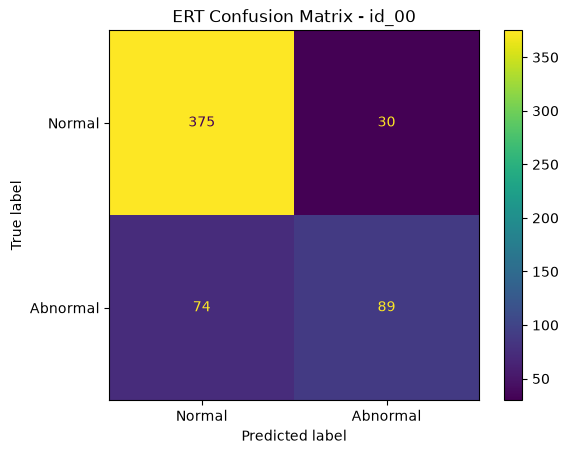


Model Saved: D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification\Fan_Module4_Output\id_00\ert_model.pkl
Predictions Saved: D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification\Fan_Module4_Output\id_00\ert_predictions.csv

ERT MODEL - MACHINE: id_02
Training Shape: (1220, 24)
Testing Shape : (550, 24)

Training ERT Model...
Training Completed!

Accuracy: 93.09%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.94      0.97      0.95       406
    Abnormal       0.90      0.83      0.86       144

    accuracy                           0.93       550
   macro avg       0.92      0.90      0.91       550
weighted avg       0.93      0.93      0.93       550

Confusion Matrix:
[[393  13]
 [ 25 119]]


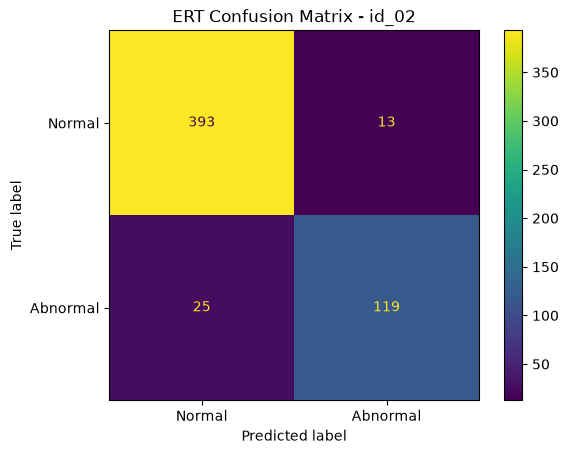


Model Saved: D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification\Fan_Module4_Output\id_02\ert_model.pkl
Predictions Saved: D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification\Fan_Module4_Output\id_02\ert_predictions.csv

ERT MODEL - MACHINE: id_04
Training Shape: (1238, 24)
Testing Shape : (553, 24)

Training ERT Model...
Training Completed!

Accuracy: 91.50%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.92      0.98      0.95       414
    Abnormal       0.91      0.73      0.81       139

    accuracy                           0.92       553
   macro avg       0.91      0.85      0.88       553
weighted avg       0.91      0.92      0.91       553

Confusion Matrix:
[[404  10]
 [ 37 102]]


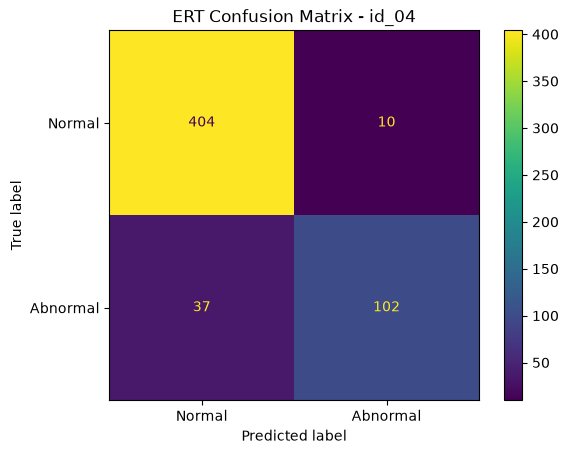


Model Saved: D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification\Fan_Module4_Output\id_04\ert_model.pkl
Predictions Saved: D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification\Fan_Module4_Output\id_04\ert_predictions.csv

ERT MODEL - MACHINE: id_06
Training Shape: (1218, 24)
Testing Shape : (551, 24)

Training ERT Model...
Training Completed!

Accuracy: 93.83%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      0.97      0.96       406
    Abnormal       0.91      0.85      0.88       145

    accuracy                           0.94       551
   macro avg       0.93      0.91      0.92       551
weighted avg       0.94      0.94      0.94       551

Confusion Matrix:
[[394  12]
 [ 22 123]]


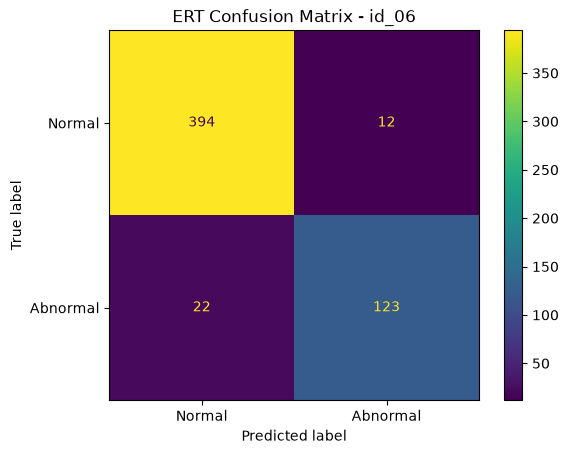


Model Saved: D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification\Fan_Module4_Output\id_06\ert_model.pkl
Predictions Saved: D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification\Fan_Module4_Output\id_06\ert_predictions.csv

MODULE 4 COMPLETED SUCCESSFULLY


,machine_id,accuracy
0,id_00,81.690141
1,id_02,93.090909
2,id_04,91.500904
3,id_06,93.829401



Accuracy Summary Saved: D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification\Fan_Module4_Output\ert_accuracy_summary.csv


In [4]:
# ============================================================
# MODULE 4: EXTRA TREES CLASSIFIER (ERT)
# Training, Evaluation and Model Saving
# ============================================================

import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------
# 1. Path Setup
# ------------------------------------------------------------

PROJECT_PATH = os.getcwd()

INPUT_PATH = os.path.join(
    PROJECT_PATH,
    "Fan_Module3_Output"
)

OUTPUT_PATH = os.path.join(
    PROJECT_PATH,
    "Fan_Module4_Output"
)

os.makedirs(
    OUTPUT_PATH,
    exist_ok=True
)

MACHINE_IDS = [
    "id_00",
    "id_02",
    "id_04",
    "id_06"
]

results = []


# ------------------------------------------------------------
# 2. Process Each Machine
# ------------------------------------------------------------

for machine_id in MACHINE_IDS:

    print("\n" + "=" * 60)
    print(f"ERT MODEL - MACHINE: {machine_id}")
    print("=" * 60)

    machine_input_path = os.path.join(
        INPUT_PATH,
        machine_id
    )

    train_file = os.path.join(
        machine_input_path,
        "train_data.csv"
    )

    test_file = os.path.join(
        machine_input_path,
        "test_data.csv"
    )

    if not os.path.exists(train_file) or not os.path.exists(test_file):
        print("Train/Test file not found!")
        continue

    # --------------------------------------------------------
    # 3. Load Train and Test Data
    # --------------------------------------------------------

    train_df = pd.read_csv(train_file)
    test_df = pd.read_csv(test_file)

    X_train = train_df.drop(
        columns=["label"]
    )

    y_train = train_df["label"]

    X_test = test_df.drop(
        columns=["label"]
    )

    y_test = test_df["label"]

    print("Training Shape:", X_train.shape)
    print("Testing Shape :", X_test.shape)


    # --------------------------------------------------------
    # 4. Create ERT Model
    # --------------------------------------------------------

    ert_model = ExtraTreesClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        class_weight=None
    )


    # --------------------------------------------------------
    # 5. Train Model
    # --------------------------------------------------------

    print("\nTraining ERT Model...")

    ert_model.fit(
        X_train,
        y_train
    )

    print("Training Completed!")


    # --------------------------------------------------------
    # 6. Prediction
    # --------------------------------------------------------

    y_pred = ert_model.predict(
        X_test
    )


    # --------------------------------------------------------
    # 7. Accuracy
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    accuracy_percentage = accuracy * 100

    print(
        f"\nAccuracy: {accuracy_percentage:.2f}%"
    )


    # --------------------------------------------------------
    # 8. Classification Report
    # --------------------------------------------------------

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Normal",
                "Abnormal"
            ],
            zero_division=0
        )
    )


    # --------------------------------------------------------
    # 9. Confusion Matrix
    # --------------------------------------------------------

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    print("Confusion Matrix:")
    print(cm)


    # --------------------------------------------------------
    # 10. Display Confusion Matrix
    # --------------------------------------------------------

    display_labels = [
        "Normal",
        "Abnormal"
    ]

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=display_labels
    )

    disp.plot(
        values_format="d"
    )

    plt.title(
        f"ERT Confusion Matrix - {machine_id}"
    )

    plt.show()


    # --------------------------------------------------------
    # 11. Save ERT Model
    # --------------------------------------------------------

    machine_output_path = os.path.join(
        OUTPUT_PATH,
        machine_id
    )

    os.makedirs(
        machine_output_path,
        exist_ok=True
    )

    model_file = os.path.join(
        machine_output_path,
        "ert_model.pkl"
    )

    joblib.dump(
        ert_model,
        model_file
    )

    print(
        "\nModel Saved:",
        model_file
    )


    # --------------------------------------------------------
    # 12. Save Prediction Results
    # --------------------------------------------------------

    prediction_df = pd.DataFrame({
        "actual_label": y_test.values,
        "predicted_label": y_pred
    })

    prediction_file = os.path.join(
        machine_output_path,
        "ert_predictions.csv"
    )

    prediction_df.to_csv(
        prediction_file,
        index=False
    )

    print(
        "Predictions Saved:",
        prediction_file
    )


    # --------------------------------------------------------
    # 13. Store Accuracy Results
    # --------------------------------------------------------

    results.append({
        "machine_id": machine_id,
        "accuracy": accuracy_percentage
    })


# ------------------------------------------------------------
# 14. Final Accuracy Summary
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

summary_file = os.path.join(
    OUTPUT_PATH,
    "ert_accuracy_summary.csv"
)

results_df.to_csv(
    summary_file,
    index=False
)

print("\n" + "=" * 60)
print("MODULE 4 COMPLETED SUCCESSFULLY")
print("=" * 60)

display(results_df)

print(
    "\nAccuracy Summary Saved:",
    summary_file
)


LDA MODEL - MACHINE: id_00
Training Shape: (1212, 24)
Testing Shape : (568, 24)

Training LDA Model...
Training Completed!

Accuracy: 75.35%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.85      0.80      0.82       405
    Abnormal       0.56      0.65      0.60       163

    accuracy                           0.75       568
   macro avg       0.71      0.72      0.71       568
weighted avg       0.77      0.75      0.76       568

Confusion Matrix:
[[322  83]
 [ 57 106]]


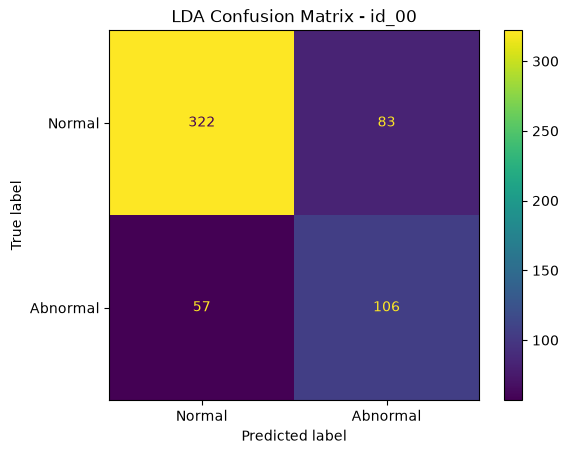


Model Saved: D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification\Fan_Module5_Output\id_00\lda_model.pkl
Predictions Saved: D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification\Fan_Module5_Output\id_00\lda_predictions.csv

LDA MODEL - MACHINE: id_02
Training Shape: (1220, 24)
Testing Shape : (550, 24)

Training LDA Model...
Training Completed!

Accuracy: 87.82%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.93      0.90      0.92       406
    Abnormal       0.75      0.81      0.78       144

    accuracy                           0.88       550
   macro avg       0.84      0.86      0.85       550
weighted avg       0.88      0.88      0.88       550

Confusion Matrix:
[[366  40]
 [ 27 117]]


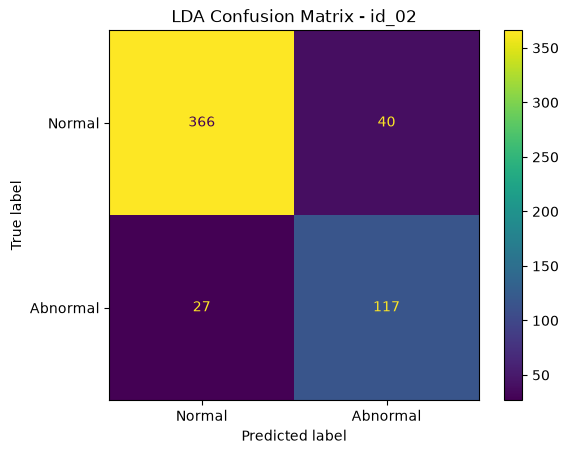


Model Saved: D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification\Fan_Module5_Output\id_02\lda_model.pkl
Predictions Saved: D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification\Fan_Module5_Output\id_02\lda_predictions.csv

LDA MODEL - MACHINE: id_04
Training Shape: (1238, 24)
Testing Shape : (553, 24)

Training LDA Model...
Training Completed!

Accuracy: 90.24%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      0.92      0.93       414
    Abnormal       0.78      0.86      0.82       139

    accuracy                           0.90       553
   macro avg       0.86      0.89      0.87       553
weighted avg       0.91      0.90      0.90       553

Confusion Matrix:
[[380  34]
 [ 20 119]]


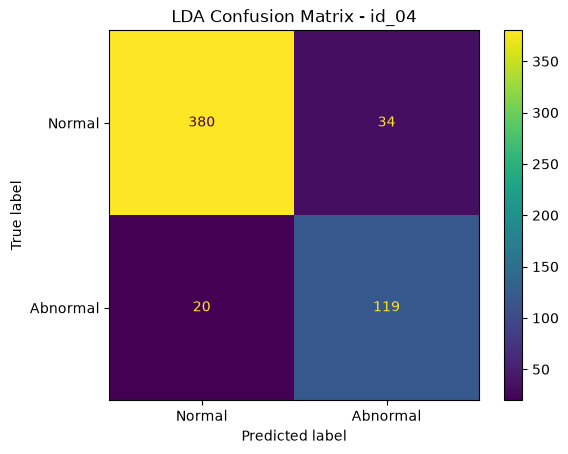


Model Saved: D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification\Fan_Module5_Output\id_04\lda_model.pkl
Predictions Saved: D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification\Fan_Module5_Output\id_04\lda_predictions.csv

LDA MODEL - MACHINE: id_06
Training Shape: (1218, 24)
Testing Shape : (551, 24)

Training LDA Model...
Training Completed!

Accuracy: 89.47%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.93      0.92      0.93       406
    Abnormal       0.79      0.81      0.80       145

    accuracy                           0.89       551
   macro avg       0.86      0.87      0.87       551
weighted avg       0.90      0.89      0.90       551

Confusion Matrix:
[[375  31]
 [ 27 118]]


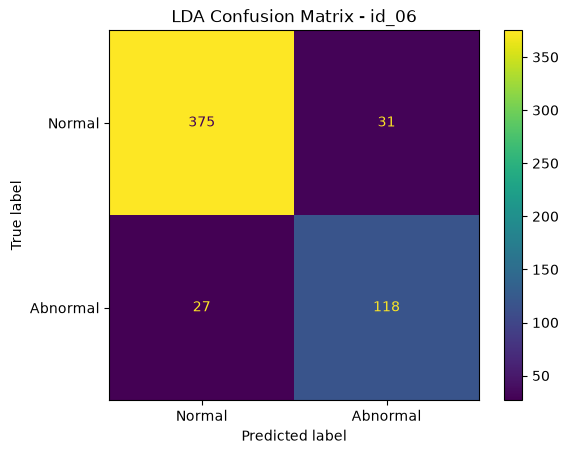


Model Saved: D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification\Fan_Module5_Output\id_06\lda_model.pkl
Predictions Saved: D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification\Fan_Module5_Output\id_06\lda_predictions.csv

MODULE 5 COMPLETED SUCCESSFULLY


,machine_id,accuracy
0,id_00,75.352113
1,id_02,87.818182
2,id_04,90.235081
3,id_06,89.473684



Accuracy Summary Saved: D:\Study Metarial\MIni_Project_PG\Industrial_Sound_Classification\Fan_Module5_Output\lda_accuracy_summary.csv


In [5]:
# ============================================================
# MODULE 5: LINEAR DISCRIMINANT ANALYSIS (LDA)
# Training, Evaluation and Model Saving
# ============================================================

import os
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------
# 1. Path Setup
# ------------------------------------------------------------

PROJECT_PATH = os.getcwd()

INPUT_PATH = os.path.join(
    PROJECT_PATH,
    "Fan_Module3_Output"
)

OUTPUT_PATH = os.path.join(
    PROJECT_PATH,
    "Fan_Module5_Output"
)

os.makedirs(
    OUTPUT_PATH,
    exist_ok=True
)

MACHINE_IDS = [
    "id_00",
    "id_02",
    "id_04",
    "id_06"
]

results = []


# ------------------------------------------------------------
# 2. Process Each Machine
# ------------------------------------------------------------

for machine_id in MACHINE_IDS:

    print("\n" + "=" * 60)
    print(f"LDA MODEL - MACHINE: {machine_id}")
    print("=" * 60)

    machine_input_path = os.path.join(
        INPUT_PATH,
        machine_id
    )

    train_file = os.path.join(
        machine_input_path,
        "train_data.csv"
    )

    test_file = os.path.join(
        machine_input_path,
        "test_data.csv"
    )

    if not os.path.exists(train_file) or not os.path.exists(test_file):
        print("Train/Test file not found!")
        continue

    # --------------------------------------------------------
    # 3. Load Train and Test Data
    # --------------------------------------------------------

    train_df = pd.read_csv(train_file)
    test_df = pd.read_csv(test_file)

    X_train = train_df.drop(
        columns=["label"]
    )

    y_train = train_df["label"]

    X_test = test_df.drop(
        columns=["label"]
    )

    y_test = test_df["label"]

    print("Training Shape:", X_train.shape)
    print("Testing Shape :", X_test.shape)


    # --------------------------------------------------------
    # 4. Create LDA Model
    # --------------------------------------------------------

    lda_model = LinearDiscriminantAnalysis()


    # --------------------------------------------------------
    # 5. Train Model
    # --------------------------------------------------------

    print("\nTraining LDA Model...")

    lda_model.fit(
        X_train,
        y_train
    )

    print("Training Completed!")


    # --------------------------------------------------------
    # 6. Prediction
    # --------------------------------------------------------

    y_pred = lda_model.predict(
        X_test
    )


    # --------------------------------------------------------
    # 7. Accuracy
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    accuracy_percentage = accuracy * 100

    print(
        f"\nAccuracy: {accuracy_percentage:.2f}%"
    )


    # --------------------------------------------------------
    # 8. Classification Report
    # --------------------------------------------------------

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Normal",
                "Abnormal"
            ],
            zero_division=0
        )
    )


    # --------------------------------------------------------
    # 9. Confusion Matrix
    # --------------------------------------------------------

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    print("Confusion Matrix:")
    print(cm)


    # --------------------------------------------------------
    # 10. Display Confusion Matrix
    # --------------------------------------------------------

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Normal",
            "Abnormal"
        ]
    )

    disp.plot(
        values_format="d"
    )

    plt.title(
        f"LDA Confusion Matrix - {machine_id}"
    )

    plt.show()


    # --------------------------------------------------------
    # 11. Save LDA Model
    # --------------------------------------------------------

    machine_output_path = os.path.join(
        OUTPUT_PATH,
        machine_id
    )

    os.makedirs(
        machine_output_path,
        exist_ok=True
    )

    model_file = os.path.join(
        machine_output_path,
        "lda_model.pkl"
    )

    joblib.dump(
        lda_model,
        model_file
    )

    print(
        "\nModel Saved:",
        model_file
    )


    # --------------------------------------------------------
    # 12. Save Prediction Results
    # --------------------------------------------------------

    prediction_df = pd.DataFrame({
        "actual_label": y_test.values,
        "predicted_label": y_pred
    })

    prediction_file = os.path.join(
        machine_output_path,
        "lda_predictions.csv"
    )

    prediction_df.to_csv(
        prediction_file,
        index=False
    )

    print(
        "Predictions Saved:",
        prediction_file
    )


    # --------------------------------------------------------
    # 13. Store Accuracy Results
    # --------------------------------------------------------

    results.append({
        "machine_id": machine_id,
        "accuracy": accuracy_percentage
    })


# ------------------------------------------------------------
# 14. Final Accuracy Summary
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

summary_file = os.path.join(
    OUTPUT_PATH,
    "lda_accuracy_summary.csv"
)

results_df.to_csv(
    summary_file,
    index=False
)

print("\n" + "=" * 60)
print("MODULE 5 COMPLETED SUCCESSFULLY")
print("=" * 60)

display(results_df)

print(
    "\nAccuracy Summary Saved:",
    summary_file
)

In [6]:
import os
import pandas as pd

PROJECT_PATH = os.getcwd()

model_folders = [
    ("Extra Trees", "Fan_Module4_Output"),
    ("LDA", "Fan_Module5_Output")
]

all_results = []

for model_name, folder_name in model_folders:

    folder_path = os.path.join(PROJECT_PATH, folder_name)

    if not os.path.exists(folder_path):
        print(f"{folder_name} not found!")
        continue

    for root, dirs, files in os.walk(folder_path):

        for file in files:

            if file.endswith(".csv"):

                file_path = os.path.join(root, file)

                try:
                    df = pd.read_csv(file_path)

                    if "accuracy" in df.columns:

                        df["Model"] = model_name
                        all_results.append(df)

                except Exception:
                    pass

if all_results:

    final_summary = pd.concat(
        all_results,
        ignore_index=True
    )

    print("=" * 70)
    print("MODEL PERFORMANCE SUMMARY")
    print("=" * 70)

    print(final_summary.to_string(index=False))

else:

    print("Accuracy summary CSV not found.")
    print("\nAvailable CSV files:")

    for model_name, folder_name in model_folders:

        folder_path = os.path.join(PROJECT_PATH, folder_name)

        for root, dirs, files in os.walk(folder_path):

            for file in files:

                if file.endswith(".csv"):
                    print(os.path.join(root, file))

MODEL PERFORMANCE SUMMARY
machine_id  accuracy       Model
     id_00 81.690141 Extra Trees
     id_02 93.090909 Extra Trees
     id_04 91.500904 Extra Trees
     id_06 93.829401 Extra Trees
     id_00 75.352113         LDA
     id_02 87.818182         LDA
     id_04 90.235081         LDA
     id_06 89.473684         LDA
